In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Validação à escala (testar os métodos com um dataset real maior)

**Objetivo:** Os métodos de recomendação (co-ocorrência, cosseno, NPMI) são adequados ao problema,
mas com os 16 produtos da JTA produzem scores fracos (matriz dispersa, NPMI normalizado). Surge então a questão:
**isso é limitação do método ou da dimensão dos dados?**

Para responder de forma honesta (sem fabricar tendência) usamos um **dataset real e maior**, transformou-se 
na **mesma estrutura** dos dados da JTA, e correu-se **exatamente os mesmos métodos** (sem os alterar).

## 1. Obter o dataset real

Usou-se o **Online Retail** (UCI / Kaggle): transações reais de uma loja online do Reino Unido
(2010–2011), milhares de produtos. É o dataset de referência para Market Basket Analysis.

In [ ]:
import pandas as pd
import numpy as np

RETAIL_PATH = "../data/Online Retail.xlsx"  

if RETAIL_PATH.endswith(".xlsx"):
    retail = pd.read_excel(RETAIL_PATH)
else:
    retail = pd.read_csv(RETAIL_PATH, encoding="ISO-8859-1")

print("Transações brutas:", retail.shape)
retail.head()


Transações brutas: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Limpeza mínima

Removemos linhas sem fatura ou sem descrição de produto, e devoluções (quantidades negativas).
Mantemos a estrutura: cada linha é (fatura, produto). Uma **fatura = uma transação/cabaz**.

In [ ]:
df = retail.copy()
df = df.dropna(subset=["InvoiceNo", "Description"])
df = df[df["Quantity"] > 0]                       # remove-se devoluções
df["Description"] = df["Description"].str.strip()
# Remove-se faturas de cancelamento
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Após limpeza:", df.shape)
print("Nº de transações (faturas):", df["InvoiceNo"].nunique())
print("Nº de produtos distintos:", df["Description"].nunique())


Após limpeza: (530693, 8)
Nº de transações (faturas): 20136
Nº de produtos distintos: 4065


## 3. Reduzir a um nº de produtos comparável e construir a estrutura do dataset da JTA

Para "manter a estrutura e aumentar em número", escolhemos os **N produtos mais
vendidos**: por exemplo 100 ou 200, em vez dos 16 da JTA. Mantém-se a mesma estrutura.

In [ ]:
N_PRODUTOS = 150  

top_produtos = (df["Description"].value_counts().head(N_PRODUTOS).index.tolist())
df_top = df[df["Description"].isin(top_produtos)]
print(f"A usar os {N_PRODUTOS} produtos mais frequentes.")


A usar os 150 produtos mais frequentes.


### 3.1 Matriz de co-ocorrência real

Para cada par de produtos, conta em quantas transações apareceram juntos. A diagonal = nº de transações em que o produto foi comprado sozinho.

In [ ]:
basket = (df_top.groupby(["InvoiceNo", "Description"])["Quantity"]
          .sum().unstack().fillna(0))
basket = (basket > 0).astype(int)


co = basket.T.dot(basket)
co = co.loc[top_produtos, top_produtos]  
print("Matriz de co-ocorrência real:", co.shape)

print("Exemplo diagonal (3 primeiros):", np.diag(co.values)[:3])


Matriz de co-ocorrência real: (150, 150)
Exemplo diagonal (3 primeiros): [2260 2092 1989]


### 3.2 Replicar a estrutura JTA

Construiu-se o dicionário de produtos com **os mesmos campos** dos dados da JTA. A repartição por lojas
é fabricada só para manter a forma (distribuímos as vendas por 3 lojas aleatoriamente).

In [ ]:
rng = np.random.default_rng(42)

produtos_real = {}
for nome in top_produtos:
    total = int(np.diag(co.values)[top_produtos.index(nome)])
    # Repartiu-se o total por 3 lojas
    pesos = rng.dirichlet([1, 1, 1])
    a, b = int(total * pesos[0]), int(total * pesos[1])
    c = total - a - b
    produtos_real[nome] = {
        "name": nome,
        "category": "Retail",         
        "type": None,
        "franchise": None,
        "min_age": None,
        "release_date": None,
        "times_sold": total,
        "store_breakdown": {"Store_A": a, "Store_B": b, "Store_C": c},
    }

print("Estrutura de um produto (igual à da JTA):")
import json
print(json.dumps(list(produtos_real.values())[0], indent=2, ensure_ascii=False))


Estrutura de um produto (igual à da JTA):
{
  "name": "WHITE HANGING HEART T-LIGHT HOLDER",
  "category": "Retail",
  "type": null,
  "franchise": null,
  "min_age": null,
  "release_date": null,
  "times_sold": 2260,
  "store_breakdown": {
    "Store_A": 762,
    "Store_B": 741,
    "Store_C": 757
  }
}


## 4. Correr os mesmos métodos (sem alterar o modelo)

Reaproveitamos a lógica do projeto. Como as funções em `tools.py` estão ligadas à matriz da JTA no
import, aqui replicamos só o **cálculo** do NPMI e do cosseno sobre a nova matriz, usando a mesma fórmula para validar o método e não o reescrever.

In [ ]:
# NPMI sem diagonal 
def build_npmi(matrix_df, include_diagonal=False):
    M = matrix_df.values.astype(float)
    diag = np.diag(M).copy()
    upper_pairs = np.triu(M, k=1).sum()
    if include_diagonal:
        N = diag.sum() + upper_pairs
        appearances = diag + (M.sum(axis=1) - diag)
    else:
        N = upper_pairs
        appearances = M.sum(axis=1) - diag
    if N <= 0:
        return np.zeros_like(M)
    p_x = appearances / N
    npmi = np.zeros_like(M)
    n = M.shape[0]
    for i in range(n):
        for j in range(n):
            if i == j: continue
            joint = M[i, j]
            if joint <= 0 or p_x[i] <= 0 or p_x[j] <= 0: continue
            p_joint = joint / N
            npmi[i, j] = np.log(p_joint/(p_x[i]*p_x[j])) / (-np.log(p_joint))
    return npmi

npmi_real = build_npmi(co, include_diagonal=False)
print("NPMI calculado para", npmi_real.shape[0], "produtos.")


NPMI calculado para 150 produtos.


## 5. Resultado

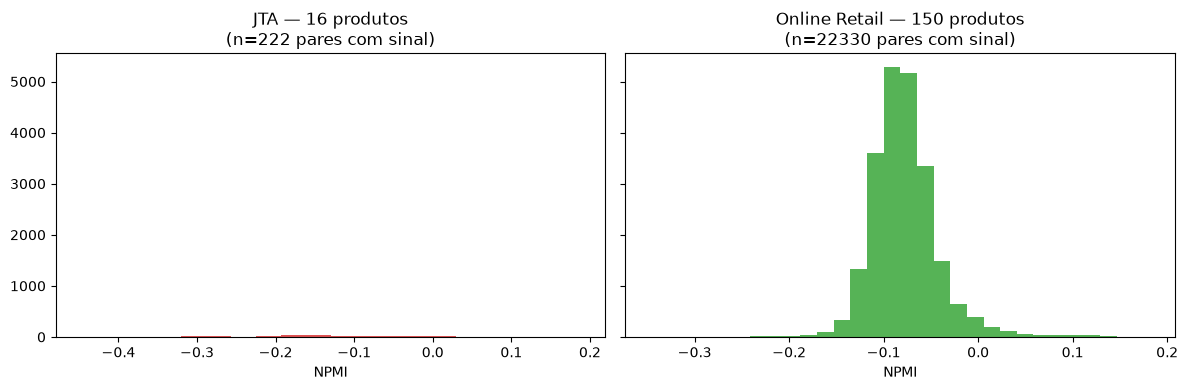

JTA   — NPMI médio: -0.1367, máx: 0.1880
Real  — NPMI médio: -0.0780, máx: 0.1819


In [ ]:
import matplotlib.pyplot as plt

# Scores NPMI fora da diagonal
vals_real = npmi_real[~np.eye(npmi_real.shape[0], dtype=bool)]
vals_real = vals_real[vals_real != 0]   # ignora pares sem co-ocorrência

# Dados JTA
from tools import _NPMI_NODIAG
vals_jta = _NPMI_NODIAG[~np.eye(_NPMI_NODIAG.shape[0], dtype=bool)]
vals_jta = vals_jta[vals_jta != 0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(vals_jta, bins=20, color="#d62728", alpha=0.8)
axes[0].set_title(f"JTA — 16 produtos\n(n={len(vals_jta)} pares com sinal)")
axes[0].set_xlabel("NPMI")
axes[1].hist(vals_real, bins=30, color="#2ca02c", alpha=0.8)
axes[1].set_title(f"Online Retail — {npmi_real.shape[0]} produtos\n(n={len(vals_real)} pares com sinal)")
axes[1].set_xlabel("NPMI")
plt.tight_layout(); plt.show()

print(f"JTA   — NPMI médio: {vals_jta.mean():.4f}, máx: {vals_jta.max():.4f}")
print(f"Real  — NPMI médio: {vals_real.mean():.4f}, máx: {vals_real.max():.4f}")


## 6. Conclusão

Se o NPMI sobre o dataset real (mais produtos) mostra associações positivas claras, ou seja, uma distribuição
mais rica e máximos mais altos do que os da JTA, isso **confirma que o método é adequado** e que a
fraqueza nos dados da JTA vem da **dimensão e esparsidade**, não de uma má escolha de método.
